In [1]:
import pandas as pd
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import numpy as np
from minio import Minio
from transformers import CLIPProcessor, CLIPModel
from concurrent.futures import ThreadPoolExecutor, as_completed

c:\Users\admin\OneDrive\Desktop\AirBNB project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h1>Setup</h1>

In [3]:
labels = '''a Lamp, a TV, a Shoreline, a Forest, a Sunset, a Fireplace, A Large Bed, a Painting, a River, a Sea, a Lake, a Balcony, a Lodge, A Treehouse, a Table, a Window, a Mirror, A Living Fence, A Remote House, a Sofa, an Indoor Plant, a Hi-Tech Room, a Garden, a Chandelier, a Carpet, a City House, a Van, a Sauna, a Watchtower, a Palm Tree, An Apartment, a Backyard'''.lower().split(', ')

In [2]:
df = pd.read_parquet('./dataset/dataset.parquet')
vc = df['city'].value_counts()
vc =  vc[vc > 2]
cities = vc.index

In [4]:
vc

city
Nashville         253
Seattle           217
Houston           210
San Francisco     206
Denver            196
Boston            149
Los Angeles       142
Cambridge          49
Somerville         24
New York           14
Topanga            14
West Hollywood     11
Spring             11
Burdett            10
Saugerties          9
Beverly Hills       9
Santa Monica        9
Kerhonkson          8
Evergreen           8
Glendale            8
Hunter              7
Brookline           7
Marina del Rey      6
Magnolia            6
Burbank             5
High Falls          5
Chicago             5
Brooklyn            5
Queens              5
Vernon              5
Culver City         5
Kingston            5
Medford             5
Golden              4
Morrison            4
Naples              4
Lakewood            4
Wheat Ridge         4
Cairo               4
Newton              4
Daly City           3
South Pasadena      3
Pattersonville      3
Woodstock           3
Lynnwood            3
Narro

In [5]:
df = df[df['city'].isin(cities)].reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         1704 non-null   float64
 1   description   1704 non-null   str    
 2   city          1704 non-null   str    
 3   guests        1704 non-null   float64
 4   bedrooms      1704 non-null   float64
 5   beds          1704 non-null   float64
 6   baths         1704 non-null   float64
 7   luxury_items  1704 non-null   float64
 8   s3_url        1704 non-null   str    
dtypes: float64(6), str(3)
memory usage: 4.1 MB


In [6]:
df

,Price,description,city,guests,bedrooms,beds,baths,luxury_items,s3_url
0,102699.0,Situated in one of Seattle's friendliest and f...,Seattle,10.0,5.0,5.0,3.5,0.0,http://localhost:9000/airbnb-images/image_1.jpg
1,208528.0,Midcentury modern 2bed/2bath stilt home with s...,Los Angeles,6.0,2.0,3.0,2.0,0.0,http://localhost:9000/airbnb-images/image_2.jpg
2,16264.0,Welcome to UNTITLED at 3 Freeman Alley!Our Stu...,New York,2.0,1.0,1.0,0.0,1.0,http://localhost:9000/airbnb-images/image_3.jpg
3,70478.0,Kick back in this peaceful room with an en-sui...,San Francisco,2.0,1.0,1.0,1.5,0.0,http://localhost:9000/airbnb-images/image_5.jpg
4,157811.0,Step into serenity at this beautifully curated...,Burbank,6.0,3.0,3.0,2.0,0.0,http://localhost:9000/airbnb-images/image_6.jpg
...,...,...,...,...,...,...,...,...,...
1699,120658.0,This spacious duplex gem in the heart of Houst...,Houston,6.0,3.0,4.0,2.0,0.0,http://localhost:9000/airbnb-images/image_2106...
1700,66435.0,"This special place is close to everything, loc...",Boston,2.0,0.0,1.0,1.0,1.0,http://localhost:9000/airbnb-images/image_2108...
1701,95358.0,Moody Blues in Music City is newly furnished!S...,Nashville,6.0,1.0,4.0,1.0,0.0,http://localhost:9000/airbnb-images/image_2109...
1702,143942.0,"Explore a beautifully reimagined luxury hotel,...",Boston,2.0,1.0,1.0,0.0,1.0,http://localhost:9000/airbnb-images/image_2110...


In [7]:
client = client = Minio(
    "localhost:9000",
    access_key="naturion",          
    secret_key="naturionbg",       
    secure=False
)

 

In [8]:
def get_image(url: str) -> Image:
  name = url.split('/')[-1]
  response = client.get_object("airbnb-images", name)
  image_data = response.read()
  response.close()
  response.release_conn()
  return Image.open(BytesIO(image_data)).convert("RGB")


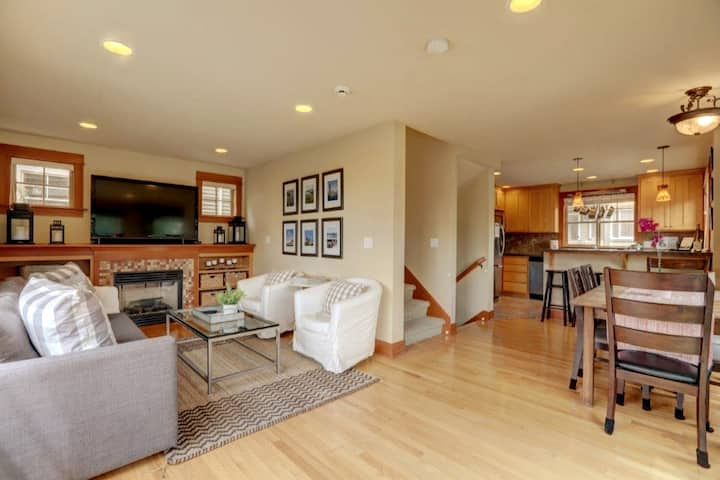

In [9]:
get_image(df.iloc[0, -1])

In [10]:
def get_CLIP_response(image: Image, model: CLIPModel, proc: CLIPProcessor) -> np.ndarray:
  inputs = proc(image, text=labels, return_tensors='pt', padding=True)
  output = model(**inputs).logits_per_image.softmax(dim=1)
  return output.detach().numpy()[0]

In [11]:
def get_top_n(response: np.ndarray, N: int = 5) -> str:
  lst = []
  for obj, prob in zip(labels, response):
    lst.append((obj, prob))
  lst = sorted(lst, key=lambda x: x[1], reverse=True)[:N] 
  s = 'This image consists of these items with highest probabilities:'
  for tup in lst:
    s+=f' {tup[0]} with probability {tup[1]};'
  return s

In [12]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")



Loading weights: 100%|██████████| 398/398 [00:00<00:00, 14992.98it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
def get_image_info(url: str, N: int = 5) -> str:
  image = get_image(url)
  response = get_CLIP_response(image, model, processor)
  return get_top_n(response, N)

In [14]:
def threading(urls: list[str] | np.ndarray, max_workers: int = 8) -> dict:
  results = {}
  with ThreadPoolExecutor(max_workers=max_workers) as executor:
    future_to_url = {executor.submit(get_image_info, url): url for url in urls}
    for future in as_completed(future_to_url):
      url = future_to_url[future]
      result = future.result()
      results[url] = result
  return results

In [15]:
col = threading(df.iloc[:, -1].values.tolist())

In [27]:
lst = [(url, sent) for url, sent in col.items()]

new_col = pd.DataFrame(lst, columns=['url', 'sentence'])

end_df = pd.merge(left=df, right=new_col, left_on='s3_url', right_on='url', how='inner').drop(columns=['url'])

end_df

,Price,description,city,guests,bedrooms,beds,baths,luxury_items,s3_url,sentence
0,102699.0,Situated in one of Seattle's friendliest and f...,Seattle,10.0,5.0,5.0,3.5,0.0,http://localhost:9000/airbnb-images/image_1.jpg,This image consists of these items with highes...
1,208528.0,Midcentury modern 2bed/2bath stilt home with s...,Los Angeles,6.0,2.0,3.0,2.0,0.0,http://localhost:9000/airbnb-images/image_2.jpg,This image consists of these items with highes...
2,16264.0,Welcome to UNTITLED at 3 Freeman Alley!Our Stu...,New York,2.0,1.0,1.0,0.0,1.0,http://localhost:9000/airbnb-images/image_3.jpg,This image consists of these items with highes...
3,70478.0,Kick back in this peaceful room with an en-sui...,San Francisco,2.0,1.0,1.0,1.5,0.0,http://localhost:9000/airbnb-images/image_5.jpg,This image consists of these items with highes...
4,157811.0,Step into serenity at this beautifully curated...,Burbank,6.0,3.0,3.0,2.0,0.0,http://localhost:9000/airbnb-images/image_6.jpg,This image consists of these items with highes...
...,...,...,...,...,...,...,...,...,...,...
1699,120658.0,This spacious duplex gem in the heart of Houst...,Houston,6.0,3.0,4.0,2.0,0.0,http://localhost:9000/airbnb-images/image_2106...,This image consists of these items with highes...
1700,66435.0,"This special place is close to everything, loc...",Boston,2.0,0.0,1.0,1.0,1.0,http://localhost:9000/airbnb-images/image_2108...,This image consists of these items with highes...
1701,95358.0,Moody Blues in Music City is newly furnished!S...,Nashville,6.0,1.0,4.0,1.0,0.0,http://localhost:9000/airbnb-images/image_2109...,This image consists of these items with highes...
1702,143942.0,"Explore a beautifully reimagined luxury hotel,...",Boston,2.0,1.0,1.0,0.0,1.0,http://localhost:9000/airbnb-images/image_2110...,This image consists of these items with highes...


In [28]:
end_df.to_parquet('./dataset/dataset_temp.parquet')